In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from dmri.simulators.global_signal_models.curves3d import sample_splines, VoxelGrid, get_average_tangent_in_voxels, get_spline_volume_fraction_in_voxels
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

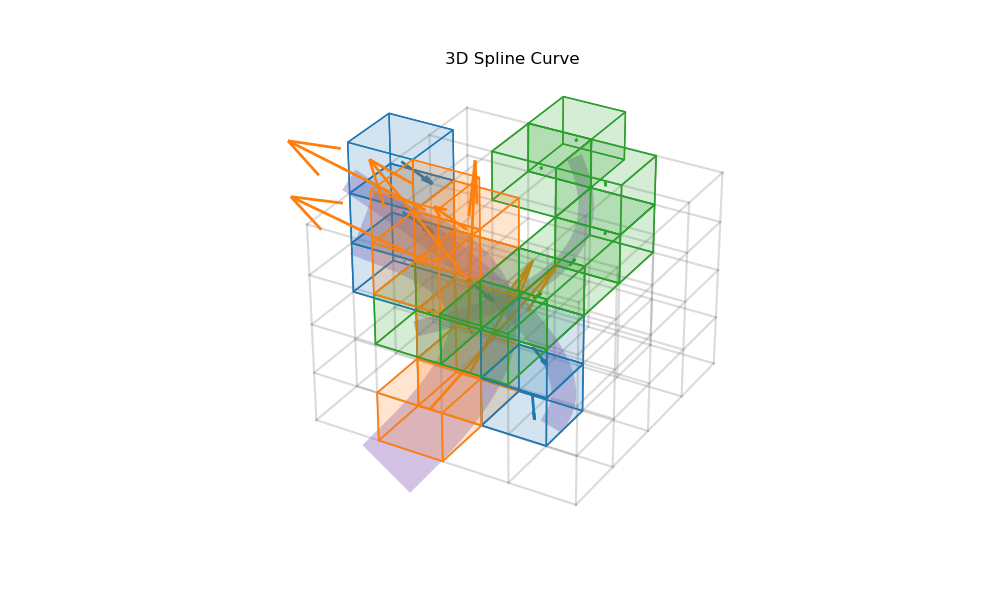

In [39]:
%matplotlib widget

from itertools import combinations, product
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
grid = VoxelGrid(4,4,4)
ax.grid(False)

grid_lines_x, grid_lines_y, grid_lines_z = grid.get_grid_lines()


start = 13
for i in range(3):
    diameter = jax.random.uniform(jax.random.key(start +100 + i), shape=(), minval=0.05, maxval=0.4)
    spline = sample_splines(jax.random.key(start + i), degree=2)
    t_line = jnp.linspace(0, 1, 100)
    spline_values = spline(t_line)
    voxel_idxs = jax.vmap(grid.get_voxel_index_for_point)(spline_values)
    voxel_idxs = jnp.unique(voxel_idxs, axis=0)

    average_tangets = get_average_tangent_in_voxels(spline, grid)
    volume_fraction = get_spline_volume_fraction_in_voxels(spline, grid,diameter)


    for voxel_idx in voxel_idxs:
        voxel_start, voxel_end = grid.get_voxel_boundaries(*voxel_idx)
        # Create a list of vertices for the 3D box
        vertices = [
            [voxel_start[0], voxel_start[1], voxel_start[2]],
            [voxel_start[0], voxel_start[1], voxel_end[2]],
            [voxel_start[0], voxel_end[1], voxel_start[2]],
            [voxel_start[0], voxel_end[1], voxel_end[2]],
            [voxel_end[0], voxel_start[1], voxel_start[2]],
            [voxel_end[0], voxel_start[1], voxel_end[2]],
            [voxel_end[0], voxel_end[1], voxel_start[2]],
            [voxel_end[0], voxel_end[1], voxel_end[2]]
        ]

        # Create a list of sides for the 3D box
        sides = [[vertices[j] for j in [0, 1, 3, 2]],
                 [vertices[j] for j in [4, 5, 7, 6]],
                 [vertices[j] for j in [0, 1, 5, 4]],
                 [vertices[j] for j in [2, 3, 7, 6]],
                 [vertices[j] for j in [0, 2, 6, 4]],
                 [vertices[j] for j in [1, 3, 7, 5]]]

        # Add the 3D box to the plot
        ax.add_collection3d(Poly3DCollection(sides, facecolors=f'C{i}', linewidths=1, edgecolors=f'C{i}', alpha=.1))

    # Plot the average tangent vectors
    for voxel_idx in voxel_idxs:
        avg_tangent = average_tangets[tuple(voxel_idx)]
        center = jnp.array(grid.get_voxel_center(*voxel_idx))
        volume = volume_fraction[tuple(voxel_idx)]
        norm = jnp.linalg.norm(avg_tangent)
        if norm > 0:
            # Calculate the endpoint to maintain the direction
            direction = avg_tangent / norm #* 0.25  # Normalize the tangent

            ax.quiver(center[0], center[1], center[2], direction[0],direction[1],direction[2], color=f'C{i}', length=volume, lw=2)

    # Plot the grid lines
    for i in range(grid_lines_x.shape[0]):
        for j in range(grid_lines_x.shape[1]):
            ax.plot(grid_lines_x[i, j, :], grid_lines_y[i, j, :], grid_lines_z[i, j, :], color='gray', alpha=0.1)
            ax.plot(grid_lines_x[i, :, j], grid_lines_y[i, :, j], grid_lines_z[i, :, j], color='gray', alpha=0.1)
            ax.plot(grid_lines_x[:, i, j], grid_lines_y[:, i, j], grid_lines_z[:, i, j], color='gray', alpha=0.1)


    # Plot the spline values
    ax.plot(spline_values[:, 0], spline_values[:, 1], spline_values[:, 2], lw=diameter*200, alpha=0.4, color=f'C{i}')


    # Set labels and show plot
    # ax.set_xlabel("X-axis")
    # ax.set_ylabel("Y-axis")
    # ax.set_zlabel("Z-axis")
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.set_title("3D Spline Curve")

plt.show()

In [374]:
start = 1
i = 0
grid = VoxelGrid(4,4,4)
diameter = jax.random.uniform(jax.random.key(start +100 + i), shape=(), minval=0.05, maxval=0.4)
spline = sample_splines(jax.random.key(start + i), degree=1)
t_line = jnp.linspace(0, 1, 100)
spline_values = spline(t_line)


voxel_idxs = jax.vmap(grid.get_voxel_index_for_point)(spline_values)
voxel_idxs = jnp.unique(voxel_idxs, axis=0)
average_tangets = get_average_tangent_in_voxels(spline, grid)
volume_fraction = get_spline_volume_fraction_in_voxels(spline, grid,diameter)

# Global simulators

In [240]:
from dmri.simulators.global_signal_models.global_ball_and_stick import GlobalBallStick

global_model = GlobalBallStick(n_voxels=4)

In [241]:
rng1, rng2, rng3, rng4 = jax.random.split(jax.random.key(2), 4)
volumes_fibers, tangent_fibers = global_model._sample_n_fibers(rng1)
fiber_fraction = global_model._fiber_conditional_fraction_prior(rng2, volumes_fibers)
fiber_direction = global_model._fiber_conditional_direction_prior(tangent_fibers, rng3)

In [242]:
bvals = jnp.array([0,0,0] + [1000]*20)
bvecs = jax.random.normal(jax.random.key(12313), (23, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=1, keepdims=True)

signal = global_model.signal(bvals, bvecs, jax.random.key(2))

In [243]:
import dipy.reconst.dti as dti
import dipy
import numpy as np

# Init gtab
gtab = dipy.core.gradients.gradient_table(bvals=bvals, bvecs=bvecs)
gtab

In [244]:
tenmodel = dti.TensorModel(gtab)

In [245]:
tenfit = tenmodel.fit(signal)

In [246]:
print('Computing anisotropy measures (FA, MD, RGB)')
from dipy.reconst.dti import fractional_anisotropy, color_fa

FA = fractional_anisotropy(tenfit.evals)
FA = np.clip(FA, 0, 1)
RGB = color_fa(FA, tenfit.evecs)

Computing anisotropy measures (FA, MD, RGB)


In [247]:
FA_true = volumes_fibers[1] > 0.

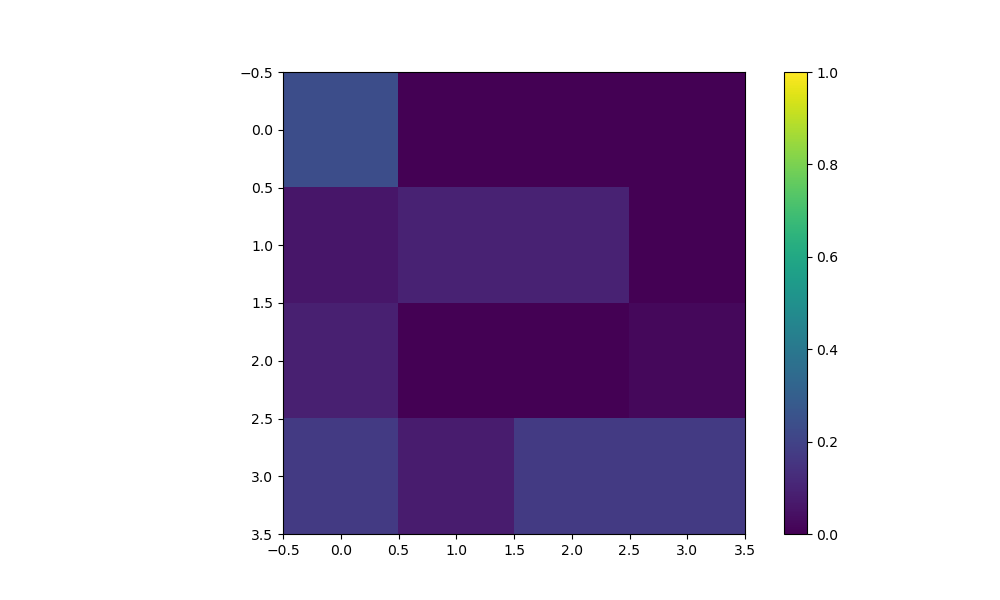

In [248]:
fig = plt.figure(figsize=(10, 6))
plt.imshow(FA[:,:,3],vmin=0,vmax=1)
plt.colorbar()

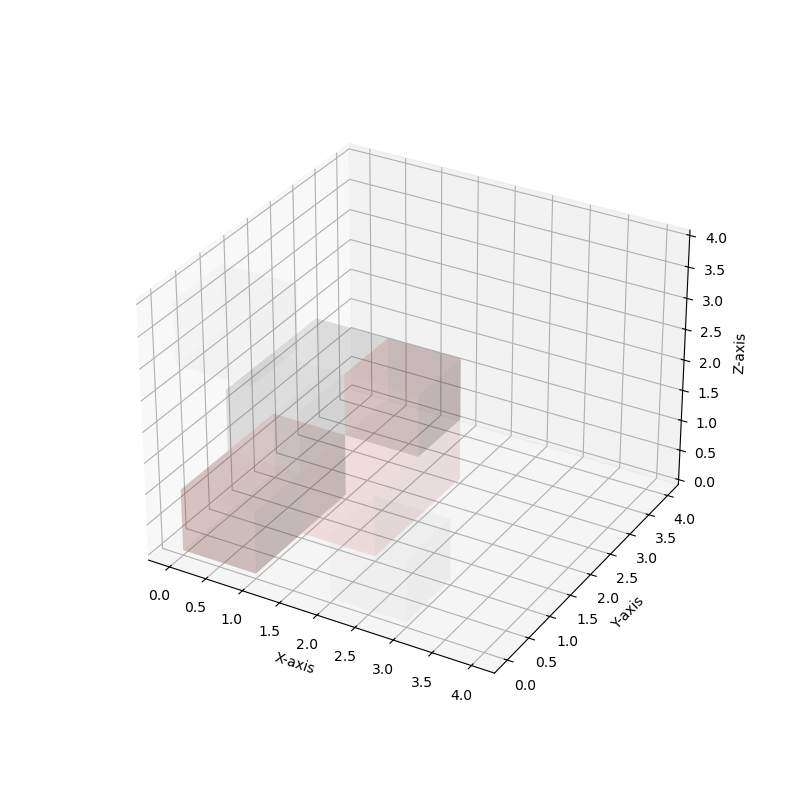

In [249]:
# Create a figure and add 3D axes
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Normalize the signal for color mapping
#normalized_signal = fiber_fraction[1]
normalized_signal = RGB.mean(-1)
fiber_present = volumes_fibers[1] > 0.
# Create a grayscale colormap
colors = plt.cm.gray(1-normalized_signal, alpha=normalized_signal*0.2)

# Set the alpha values based on the normalized signal
alphas = normalized_signal

# Plot the voxels with color and alpha dependent on the value
ax.voxels(normalized_signal>0.1, facecolors=colors, edgecolor=None)
ax.voxels(FA_true > 0.5, facecolors='red', edgecolor=None, alpha=0.05)
# Show the plot
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.show()


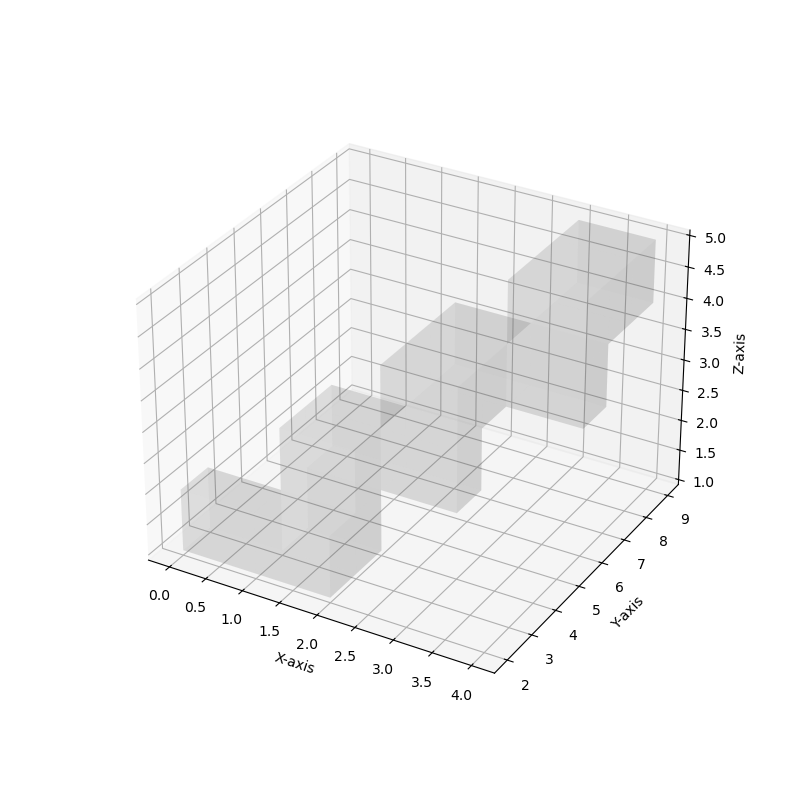

In [237]:
# Create a figure and add 3D axes
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Normalize the signal for color mapping
#normalized_signal = fiber_fraction[1]
normalized_signal = FA



# Plot the voxels with color and alpha dependent on the value
ax.voxels(normalized_signal > 0.5, facecolors="grey", edgecolor=None, alpha=0.1)
#ax.voxels(FA_true, facecolors='red', edgecolor=None, alpha=0.05)
# Show the plot
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.show()


Computing tensor ellipsoids in a part of the splenium of the CC
Saving illustration as tensor_ellipsoids.png


/tmp/ipykernel_26198/207572739.py:4: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere = get_sphere('symmetric724')
/root/miniconda3/envs/dipy/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3577: UserWarning: We'll no longer accept the way you call the record function in future versions of FURY.

Here's how to call the Function record: record(scene='value', cam_pos='value', cam_focal='value', cam_view='value', out_path='value', path_numbering='value', n_frames='value', az_ang='value', magnification='value', size='value', reset_camera='value', screen_clip='value', stereo='value', verbose='value')

  exec(code_obj, self.user_global_ns, self.user_ns)


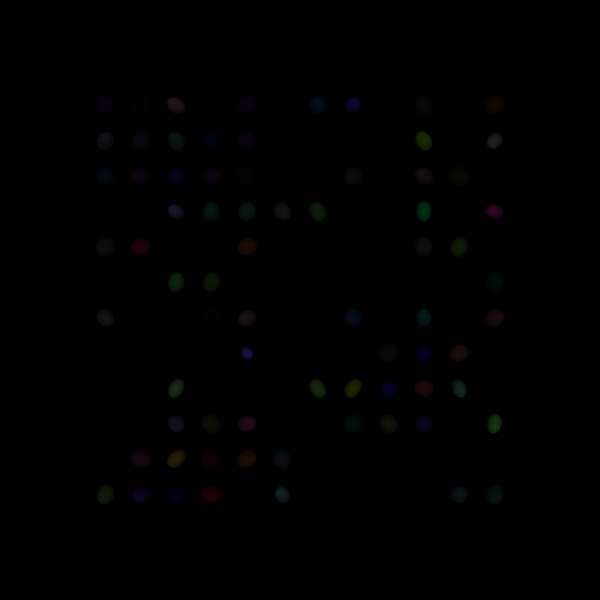

In [238]:
print('Computing tensor ellipsoids in a part of the splenium of the CC')

from dipy.data import get_sphere
sphere = get_sphere('symmetric724')

from dipy.viz import window, actor

# Enables/disables interactive visualization
interactive = False

ren = window.Scene()

evals = tenfit.evals
evecs = tenfit.evecs

cfa = RGB
cfa /= cfa.max()

ren.add(actor.tensor_slicer(evals, evecs, scalar_colors=cfa, sphere=sphere, scale=0.3))

print('Saving illustration as tensor_ellipsoids.png')
window.record(ren, n_frames=1, out_path='tensor_ellipsoids.png', size=(600, 600))
if interactive:
    window.show(ren)
from IPython.display import Image, display

# Load and display the image
image_path = 'tensor_ellipsoids.png'
display(Image(filename=image_path))

In [239]:
tenfit.evals

array([[[[9.25837840e-03, 8.56642291e-03, 8.55698950e-03],
         [4.77325339e-03, 3.77636070e-03, 3.77621265e-03],
         [9.21034125e-03, 9.21033995e-03, 9.21033931e-03],
         ...,
         [8.39605391e-03, 7.51326215e-03, 7.50994165e-03],
         [9.21034125e-03, 9.21033995e-03, 9.21033931e-03],
         [9.09767358e-03, 8.33452826e-03, 8.33198202e-03]],

        [[9.21034125e-03, 9.21033995e-03, 9.21033931e-03],
         [9.21034125e-03, 9.21033995e-03, 9.21033931e-03],
         [9.21034125e-03, 9.21033995e-03, 9.21033931e-03],
         ...,
         [9.21034125e-03, 9.21033995e-03, 9.21033931e-03],
         [5.96804169e-03, 4.97736360e-03, 4.97711747e-03],
         [3.64927670e-03, 2.65023798e-03, 2.65019106e-03]],

        [[7.37391282e-03, 6.41433136e-03, 6.41377007e-03],
         [1.00001057e-03, 1.06655662e-08, 1.05519343e-08],
         [6.19901194e-03, 5.21209520e-03, 5.21159137e-03],
         ...,
         [9.21034125e-03, 9.21033995e-03, 9.21033931e-03],
         [

Saving illustration as tensor_odfs.png


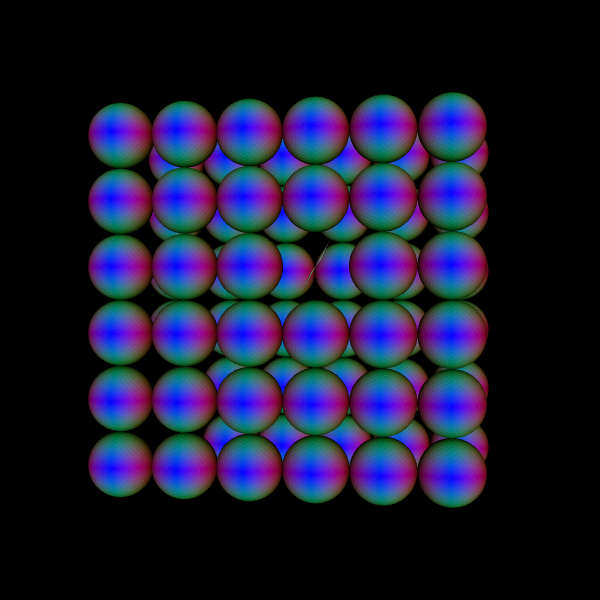

In [20]:
interactive = False
tensor_odfs = tenmodel.fit(signal[:,:, 0:1]).odf(sphere)
odf_actor = actor.odf_slicer(tensor_odfs, sphere=sphere, scale=0.5, colormap=None)
ren.add(odf_actor)
print('Saving illustration as tensor_odfs.png')
window.record(ren, n_frames=1, out_path='tensor_odfs.png', size=(600, 600))
if interactive:
    window.show(ren)

# Load and display the image
image_path = 'tensor_odfs.png'
display(Image(filename=image_path))

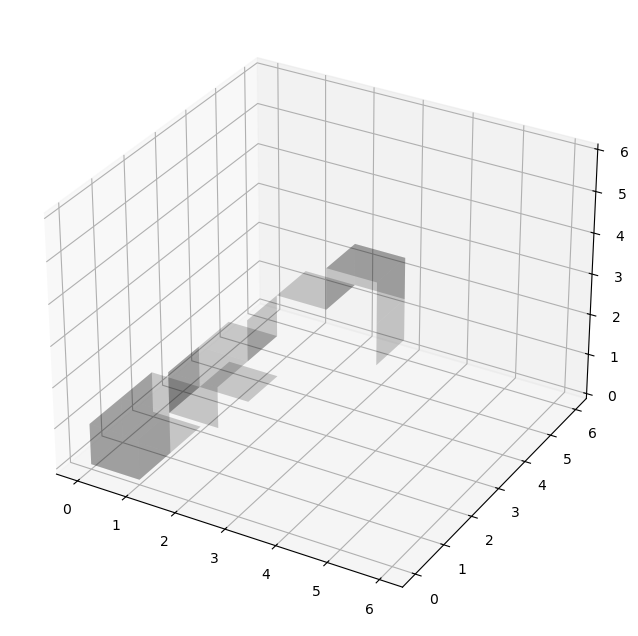

In [35]:
# Create a figure and add 3D axes
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Normalize the signal for color mapping
#normalized_signal = fiber_fraction[1]
normalized_signal = FA
# Create a grayscale colormap
colors = plt.cm.gray(1-normalized_signal, alpha=normalized_signal*0.2)

# Set the alpha values based on the normalized signal
alphas = normalized_signal

# Plot the voxels with color and alpha dependent on the value
ax.voxels(normalized_signal, facecolors=colors, edgecolor=None)

# Show the plot
plt.show()
